In [1]:
!pip install h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 4.3 MB/s eta 0:00:00


In [6]:
#mount google drive
from google.colab import drive
import os
drive.mount('/content/drive')
CSV_PATH  = os.path.join(os.getcwd(),'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data', 'merged_data', 'train_combined.csv')
CHALLENGE_DATA_PATH = os.path.join(os.getcwd(),'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data', 'merged_data')
SUBMISSION_PATH = os.getcwd()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Task 4.5 — Geo Mean HAI Across All Variants (D28)

**4.5 Predict antibody breadth — all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Geo mean / Metric: Spearman correlation
* Full description: Geometric mean HAI titer across all measured variants at Day 28

---

## Design notes

**y-values:** `breadth_delta` = log2(geomean HAI D28) − log2(geomean HAI D0), computed from the 17 challenge strains (16/17 have D28 data in training; `H3N2 A/Massachusetts/18/2022` is missing). Only participants with ≥ `MIN_STRAINS` strains at both D0 and D28 are included. Evaluation reconstructs final log2 D28 geomeans as `geomean_d0 + predicted_breadth_delta` before computing Spearman against actual `geomean_d28`.

**Output scale:** Challenge CSV uses `np.exp2(geomean_d0_challenge + predicted_breadth_delta)` — the raw geometric mean HAI titer at D28.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [11]:
TARGET_COL = 'breadth_delta'
AUTOML_MAX_MODELS = 60
AUTOML_SEED = 1
AUTO_ML_MAX_RUNTIME_SECONDS = 60 * 60
ONLY_TRANSCRIPTOMICS_PARTICIPANTS = False
FORCE_KEEP_TRANSCRIPTOMICS = True
MISSING_THRESHOLD = 0.8
MIN_STRAINS = 7

In [ ]:
CSV_PATH = '../cleaned_data/train_combined.csv'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = 'submission'

In [8]:
import io
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [9]:
challenge_data = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_combined.csv')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 311)


---
## Preprocessing

Each step prints shape after filtering. The same coercions applied to training data are applied to challenge data in the same cell.

### Preprocessing — define challenge strains and compute target

Define the 17 challenge strains, compute log2-geomeans at D0 and D28 for each training participant,
and set `breadth_delta = geomean_d28 − geomean_d0`. Challenge data gets the same `geomean_d0`
computation — it is needed later to reconstruct the raw geomean HAI at D28 for the submission.

In [10]:
CHALLENGE_STRAINS = [
    'H1N1 A/California/7/2009',
    'H1N1 A/Brisbane/2/2018',
    'H1N1 A/Guangdong-Maonan/SWL1536/2019',
    'H1N1 A/Victoria/2570/2019',
    'H1N1 A/Victoria/4897/2022',
    'H3N2 A/Hong Kong/4801/2014',
    'H3N2 A/Singapore/INFIMH-160019/2016',
    'H3N2 A/Kansas/14/2017',
    'H3N2 A/Hong Kong/2671/2019',
    'H3N2 A/South Australia/34/2019',
    'H3N2 A/Tasmania/503/2020',
    'H3N2 A/Darwin/9/2021',
    'H3N2 A/Massachusetts/18/2022',
    'Vic B/Colorado/6/2017',
    'Vic B/Washington/2/2019',
    'Vic B/Austria/1359417/2021',
    'Yam B/Phuket/3073/2013',
]

df = pd.read_csv(CSV_PATH)
print(f'Pre-filtered shape: {df.shape}')

d0_cols = [f'HAI_{s}_d0' for s in CHALLENGE_STRAINS if f'HAI_{s}_d0' in df.columns]
d28_cols = [f'HAI_{s}_d28' for s in CHALLENGE_STRAINS if f'HAI_{s}_d28' in df.columns]
print(f'Challenge strains with D0 data: {len(d0_cols)} / {len(CHALLENGE_STRAINS)}')
print(f'Challenge strains with D28 data: {len(d28_cols)} / {len(CHALLENGE_STRAINS)}')

df['geomean_d0'] = df[d0_cols].mean(axis=1, skipna=True)
df['geomean_d28'] = df[d28_cols].mean(axis=1, skipna=True)
df['n_strains_d0'] = df[d0_cols].notna().sum(axis=1)
df['n_strains_d28'] = df[d28_cols].notna().sum(axis=1)
df[TARGET_COL] = df['geomean_d28'] - df['geomean_d0']

# Challenge: same geomean_d0 needed to reconstruct raw D28 titer at predict time
d0_cols_chal = [f'HAI_{s}_d0' for s in CHALLENGE_STRAINS if f'HAI_{s}_d0' in challenge_data.columns]
challenge_data['geomean_d0'] = challenge_data[d0_cols_chal].mean(axis=1, skipna=True)
print(f'Challenge geomean_d0 computed from {len(d0_cols_chal)} strains.')

Pre-filtered shape: (3757, 489)
Challenge strains with D0 data: 16 / 17
Challenge strains with D28 data: 16 / 17
Challenge geomean_d0 computed from 17 strains.


### Filter by minimum strain coverage

Keep only participants with ≥ `MIN_STRAINS` strains measured at both D0 and D28 so the geomean is
based on enough data points to be meaningful.

In [12]:
df = df[
    (df['n_strains_d0'] >= MIN_STRAINS) &
    (df['n_strains_d28'] >= MIN_STRAINS) &
    df[TARGET_COL].notna()
].reset_index(drop=True)
print(f'After MIN_STRAINS={MIN_STRAINS} and target-notna filter: {df.shape}')

After MIN_STRAINS=7 and target-notna filter: (1282, 494)


### Drop all-null columns

In [13]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns. New shape: {df.shape}')

Dropped 127 all-null columns. New shape: (1282, 367)


### Coerce HAI string columns to numeric

Some `HAI_*` titer columns are stored as strings (e.g. censored values like `<10` or stringified NaN).
H2O treats those as categorical at training time but numeric at prediction time, which crashes `predict()`.
We coerce all `HAI_*` string columns to numeric (non-numeric values become NaN). Genuine categoricals
(demographics) are left alone.

In [ ]:
# str_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
# print(f'String columns ({len(str_cols)}):', str_cols)

# hai_str_cols = [c for c in str_cols if c.startswith('HAI_')]
# for c in hai_str_cols:
#     df[c] = pd.to_numeric(df[c], errors='coerce')
# print(f'\nCoerced {len(hai_str_cols)} HAI string columns to numeric.')
# print(f'Remaining string columns: {df.select_dtypes(include=["object", "str"]).columns.tolist()}')

# # Apply same coercion to challenge data so type mismatch can't crash predict()
# challenge_hai_str_cols = [c for c in challenge_data.select_dtypes(include=['object', 'str']).columns
#                           if c.startswith('HAI_')]
# for c in challenge_hai_str_cols:
#     challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
# print(f'Coerced {len(challenge_hai_str_cols)} HAI string columns in challenge data.')

### Drop constant features

Any column with only one unique value (numeric or categorical) carries no signal. Since we filtered
to participants with this target, some categorical features may collapse to a single value here.

In [14]:
constant_cols = [c for c in df.columns
                 if c != TARGET_COL and df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=constant_cols)
print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Shape: {df.shape}')

Dropped 0 constant columns: []
Shape: (1282, 367)


### Transcriptomics stats

In [15]:
tran_cols = [c for c in df.columns if c.startswith('TRAN_')]
df_tran = df[df[tran_cols].notna().any(axis=1)].reset_index(drop=True)
print(f'Participants with TRAN data: {df_tran.shape[0]} / {df.shape[0]} '
      f'({df_tran.shape[0] / df.shape[0]:.1%})')

if ONLY_TRANSCRIPTOMICS_PARTICIPANTS:
    df = df_tran
    print(f'Filtered df to TRAN-only participants. Shape: {df.shape}')

Participants with TRAN data: 323 / 1282 (25.2%)


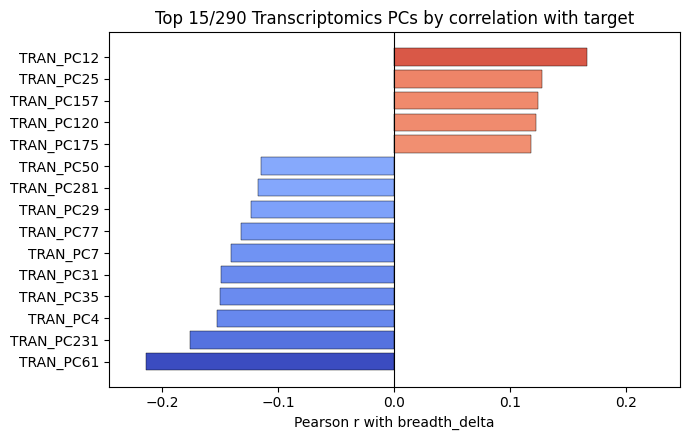

In [16]:
num_to_show = 15
tran_corrs = df_tran[tran_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
top = tran_corrs.loc[tran_corrs.abs().sort_values(ascending=False).head(num_to_show).index]
top = top.sort_values()

vmax = top.abs().max()
colors = plt.cm.coolwarm((top.values / vmax + 1) / 2)

fig, ax = plt.subplots(figsize=(7, max(4, num_to_show * 0.3)))
ax.barh(top.index, top.values, color=colors, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Pearson r with {TARGET_COL}')
ax.set_title(f'Top {num_to_show}/{len(tran_cols)} Transcriptomics PCs by correlation with target')
ax.set_xlim(-vmax * 1.15, vmax * 1.15)
plt.tight_layout()
plt.show()

### Drop sparse features

Drop columns missing in more than `MISSING_THRESHOLD` of rows — too gappy for tree models to learn
from and slow training enough that only GLMs finish.

In [17]:
miss_frac = df.isna().mean()
sparse_cols = miss_frac[miss_frac > MISSING_THRESHOLD].index

if FORCE_KEEP_TRANSCRIPTOMICS:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL and c not in tran_cols]
else:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL]

df = df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns with >{MISSING_THRESHOLD:.0%} missing.')
print(f'Shape: {df.shape}')

Dropped 3 columns with >80% missing.
Shape: (1282, 364)


In [18]:
surviving_tran = [c for c in df.columns if c.startswith('TRAN_')]
print(f'TRAN columns surviving sparse filter: {len(surviving_tran)} / {len(tran_cols)}')

TRAN columns surviving sparse filter: 290 / 290


### Drop other-task target columns

The challenge participants only have baseline data (demographics + d0 + d7) — d28 and d365
measurements don't exist for them yet. Also drop the constructed `geomean_d28` and `n_strains_*`
columns which are unavailable at prediction time.

In [19]:
leakage_cols = [c for c in df.columns
                if (c.endswith('_d28') and c != TARGET_COL) or c.endswith('_d365')]
leakage_cols += [c for c in ('geomean_d28', 'n_strains_d0', 'n_strains_d28') if c in df.columns]
leakage_cols = list(dict.fromkeys(leakage_cols))
df = df.drop(columns=leakage_cols)
print(f'Dropped {len(leakage_cols)} leakage columns.')
print(f'Final shape: {df.shape}')

Dropped 43 leakage columns.
Final shape: (1282, 321)


In [20]:
# Force float64 on all remaining HAI feature columns to prevent H2O from mistyping
# sparsely-populated columns as categorical, which crashes predict() on the challenge set.
hai_feature_cols = [c for c in df.columns if c.startswith('HAI_') and c != TARGET_COL]
for c in hai_feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    if c in challenge_data.columns:
        challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Forced float64 on {len(hai_feature_cols)} HAI feature columns in training and challenge data.')

Forced float64 on 25 HAI feature columns in training and challenge data.


In [21]:
print(f'Final shape: {df.shape}')
print(f'Target ({TARGET_COL}) stats (log2 delta):\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')

Final shape: (1282, 321)
Target (breadth_delta) stats (log2 delta):
count    1282.000000
mean        1.017780
std         0.913924
min        -1.066667
25%         0.400000
50%         0.800000
75%         1.466667
max         4.933333
Name: breadth_delta, dtype: float64

dtype counts:
float64    318
object       3
Name: count, dtype: int64


In [22]:
# filter out any columns that are not common to the train and challenge data
train_feature_cols = [c for c in df.columns if c != TARGET_COL]
common_feature_cols = [c for c in train_feature_cols if c in challenge_data.columns]

train_only_cols = sorted(set(train_feature_cols) - set(common_feature_cols))
challenge_only_cols = sorted(set(challenge_data.columns) - set(common_feature_cols))

df = df[common_feature_cols + [TARGET_COL]].copy()
challenge_data = challenge_data[common_feature_cols].copy()

# Keep downstream H2O column-type helpers aligned with the filtered feature set.
hai_feature_cols = [c for c in hai_feature_cols if c in common_feature_cols]
surviving_tran = [c for c in surviving_tran if c in common_feature_cols]

print(f'Train-only feature columns dropped: {len(train_only_cols)}')
print(f'Challenge-only columns dropped: {len(challenge_only_cols)}')
print(f'Aligned training shape: {df.shape}')
print(f'Aligned challenge shape: {challenge_data.shape}')
print(f'Train/challenge feature columns match: {common_feature_cols == challenge_data.columns.tolist()}')

Train-only feature columns dropped: 10
Challenge-only columns dropped: 2
Aligned training shape: (1282, 311)
Aligned challenge shape: (40, 310)
Train/challenge feature columns match: True


---
## AutoML Setup

In [23]:
warnings.filterwarnings('ignore', category=UserWarning, module='h2o')
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpnp1snghb
  JVM stdout: /tmp/tmpnp1snghb/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpnp1snghb/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,10 days
H2O_cluster_name:,H2O_from_python_unknownUser_sg5u5u
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,12.75 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [24]:
hai_col_types = {c: 'real' for c in hai_feature_cols}
tran_col_types = {c: 'real' for c in surviving_tran}
col_types = {**hai_col_types, **tran_col_types}
data = h2o.H2OFrame(df, column_types=col_types)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (1282, 311)


---
## AutoML Training

In [25]:
y = TARGET_COL
x = [c for c in data.columns if c not in (y, 'participant_id')]
print(f'Training samples: {data.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(
    max_models=AUTOML_MAX_MODELS,
    seed=AUTOML_SEED,
    nfolds=5,
    keep_cross_validation_predictions=True,
    max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS,
)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=data)
print('Training complete.')

Training samples: 1282  |  Features: 309
Training complete.


In [26]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
lb_df

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,StackedEnsemble_AllModels_1_AutoML_1_20260602_...,0.796373,0.634210,0.612608,None,0.634210
1,StackedEnsemble_BestOfFamily_1_AutoML_1_202606...,0.797491,0.635992,0.616978,None,0.635992
2,GBM_grid_1_AutoML_1_20260602_70323_model_2,0.815101,0.664390,0.630708,None,0.664390
3,GBM_5_AutoML_1_20260602_70323,0.817312,0.667999,0.639976,None,0.667999
4,GBM_grid_1_AutoML_1_20260602_70323_model_9,0.817509,0.668321,0.632178,None,0.668321
...,...,...,...,...,...,...
57,DeepLearning_grid_1_AutoML_1_20260602_70323_mo...,0.914867,0.836981,0.694192,None,0.836981
58,XGBoost_grid_1_AutoML_1_20260602_70323_model_10,0.920065,0.846519,0.704154,None,0.846519
59,XGBoost_grid_1_AutoML_1_20260602_70323_model_17,0.922308,0.850653,0.717167,None,0.850653
60,XGBoost_grid_1_AutoML_1_20260602_70323_model_14,0.927079,0.859476,0.716424,None,0.859476


Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Prediction model:  StackedEnsemble_AllModels_1_AutoML_1_20260602_70323
Scoring model:     GBM_grid_1_AutoML_1_20260602_70323_model_2
Task 4.5 — Spearman on final geomean D28 (best base model 5-fold CV): 0.754  (p=0.0000)


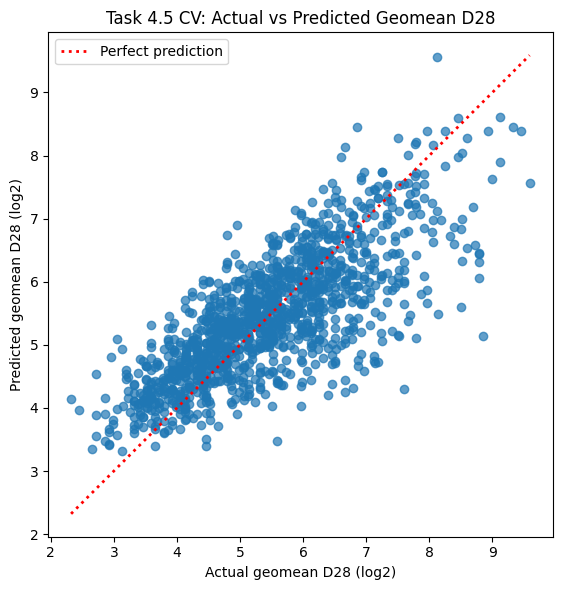

In [27]:
# Best overall (may be a StackedEnsemble) — used for predictions and saved as the deliverable
top_model = h2o.get_model(lb_df['model_id'].iloc[0])

# Best non-ensemble — used for Spearman CV and varimp, since StackedEnsembles don't expose
# cross-validation holdout predictions in the same way base models do.
top_base_model_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
top_base_model = h2o.get_model(top_base_model_id)

cv_pred_delta = top_base_model.cross_validation_holdout_predictions().as_data_frame(use_multi_thread=True)['predict']
actual_delta = data[y].as_data_frame(use_multi_thread=True)[y]
baseline_geomean_d0 = data['geomean_d0'].as_data_frame(use_multi_thread=True)['geomean_d0']

actual_geomean_d28 = baseline_geomean_d0 + actual_delta
pred_geomean_d28 = baseline_geomean_d0 + cv_pred_delta
valid_eval = actual_geomean_d28.notna() & pred_geomean_d28.notna()

rho, pval = spearmanr(actual_geomean_d28[valid_eval], pred_geomean_d28[valid_eval])
print(f'Prediction model:  {top_model.model_id}')
print(f'Scoring model:     {top_base_model.model_id}')
print(f'Task 4.5 — Spearman on final geomean D28 (best base model 5-fold CV): {rho:.3f}  (p={pval:.4f})')

axis_min = min(actual_geomean_d28[valid_eval].min(), pred_geomean_d28[valid_eval].min())
axis_max = max(actual_geomean_d28[valid_eval].max(), pred_geomean_d28[valid_eval].max())

plt.figure(figsize=(6, 6))
plt.scatter(actual_geomean_d28[valid_eval], pred_geomean_d28[valid_eval], alpha=0.7)
plt.plot([axis_min, axis_max], [axis_min, axis_max], color='red', linestyle=':', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual geomean D28 (log2)')
plt.ylabel('Predicted geomean D28 (log2)')
plt.title('Task 4.5 CV: Actual vs Predicted Geomean D28')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

Best base model: GBM_grid_1_AutoML_1_20260602_70323_model_2


,variable,relative_importance,scaled_importance,percentage
0,PART_age,291.768951,1.000000,0.107617
1,HAI_Vic B/Austria/1359417/2021_d0,225.019455,0.771225,0.082997
2,geomean_d0,173.946625,0.596179,0.064159
3,HAI_H3N2 A/Hong Kong/4801/2014_d0,166.004593,0.568959,0.061230
4,HAI_H1N1 A/Victoria/2570/2019_d0,152.823349,0.523782,0.056368
5,HAI_Vic B/Washington/2/2019_d0,140.921799,0.482991,0.051978
6,HAI_H3N2 A/Tasmania/503/2020_d0,122.038689,0.418272,0.045013
7,HAI_H3N2 A/Darwin/9/2021_d0,94.149002,0.322683,0.034726
8,HAI_H1N1 A/California/7/2009_d0,78.302269,0.268371,0.028881
9,TRAN_PC115,76.912918,0.263609,0.028369


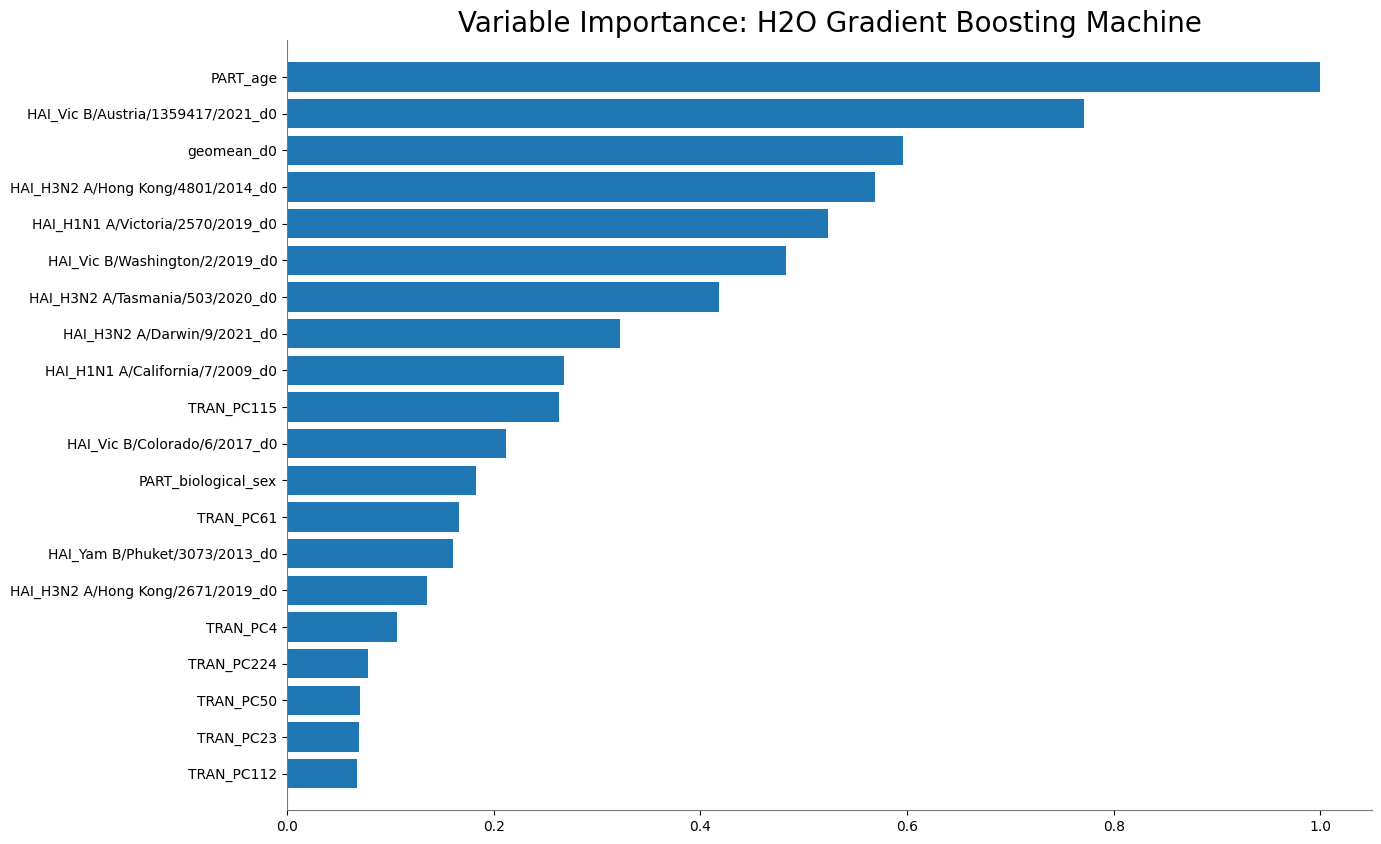

<Figure size 640x480 with 0 Axes>

In [28]:
print(f'Best base model: {top_base_model.model_id}')
varimp = top_base_model.varimp(use_pandas=True)
display(varimp.head(20))
top_base_model.varimp_plot(num_of_features=20)

In [32]:
challenge_col_types = {c: 'real' for c in hai_feature_cols if c in challenge_data.columns}
challenge_col_types.update({c: 'real' for c in surviving_tran if c in challenge_data.columns})
challenge_hf = h2o.H2OFrame(challenge_data, column_types=challenge_col_types)
y_pred = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

challenge_geomean_d0 = challenge_data['geomean_d0'].values

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.5*': np.exp2(challenge_geomean_d0 + y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_5.csv', index=False)
results

H2OConnectionError: Connection was closed, and can no longer be used.

In [30]:
model_path = h2o.save_model(model=top_model, path='.', filename='models/model_4.5', force=True)
print(f'Model saved to: {model_path}')

Model saved to: /content/models/model_4.5


In [31]:
h2o.cluster().shutdown()

H2O session _sid_9f08 closed.


---
## Conclusion

- **Leader model:** TBD (re-run to populate)
- **Scoring model:** TBD (best non-StackedEnsemble base, used for CV Spearman)
- **CV Spearman:** TBD
- **Training samples:** TBD | **Features:** TBD
- **Model saved:** `automl_models/models/model_4.5`

**Target:** `breadth_delta` = log2(geomean HAI D28) − log2(geomean HAI D0) across up to 16/17
challenge strains with D28 data in training. `H3N2 A/Massachusetts/18/2022` has no D28 data and
is excluded from D28 averaging. Only participants with ≥ `MIN_STRAINS` strains at both timepoints
are included as training rows.

**Output:** `np.exp2(geomean_d0_challenge + predicted_breadth_delta)` — raw geometric mean HAI
titer at D28 for each challenge participant.

**Feature set:** demographics + HAI d0/d7 columns + TRAN PCs from `combined.csv`, after dropping
columns >80% missing and all d28/d365 leakage columns. `FORCE_KEEP_TRANSCRIPTOMICS = True`
preserves all TRAN PCs regardless of sparsity. All HAI and TRAN columns are explicitly typed
`real` on both training and challenge H2OFrames to prevent auto-type mismatches.

**Imputation note:** No manual imputation. H2O's tree models handle `NaN` natively at each split,
eliminating leakage that would arise from pre-computing medians on the full training set.

Submission saved to `submission/task_4_5.csv`.

To reload the model: `h2o.load_model('automl_models/models/model_4.5')`

#Experimental: use task4.5 model to predict other tasks.

ex) 4.1 predicted = 4.1 d0 + breadth delta predicted by 4.5 model

In [37]:
import h2o
warnings.filterwarnings('ignore', category=UserWarning, module='h2o')
h2o.init()

# Load the previously saved model
top_model = h2o.load_model(model_path)

challenge_col_types = {c: 'real' for c in hai_feature_cols if c in challenge_data.columns}
challenge_col_types.update({c: 'real' for c in surviving_tran if c in challenge_data.columns})
challenge_hf = h2o.H2OFrame(challenge_data, column_types=challenge_col_types)
y_pred = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

orig_challenge_data = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_combined.csv')
d0 = orig_challenge_data['HAI_H3N2 A/Massachusetts/18/2022_d0'].values

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.2': np.exp2(d0 + y_pred),
})

results.to_csv(f'{SUBMISSION_PATH}/task_4_2.csv', index=False)
print("Predictions re-generated and saved to submission/task_4_2.csv")
display(results)

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,9 mins 50 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,10 days
H2O_cluster_name:,H2O_from_python_unknownUser_1y1nez
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,12.67 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Predictions re-generated and saved to submission/task_4_2.csv


,Participant_ID,Task_4.2
0,2024_UGA.ID_077,8.823564
1,2024_UGA.ID_086,9.334383
2,2024_UGA.ID_128,302.587418
3,2024_UGA.ID_170,329.559941
4,2024_UGA.ID_179,23.623608
5,2024_UGA.ID_215,28.989116
6,2024_UGA.ID_219,39.357136
7,2024_UGA.ID_275,12.232211
8,2024_UGA.ID_295,21.607408
9,2024_UGA.ID_296,8.566593


In [39]:
#predict 4.1

d0 = orig_challenge_data['HAI_H1N1 A/Victoria/4897/2022_d0'].values
results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.1': np.exp2(d0 + y_pred),
})

results.to_csv(f'{SUBMISSION_PATH}/task_4_1.csv', index=False)
print("Predictions re-generated and saved to submission/task_4_1.csv")
display(results)

Predictions re-generated and saved to submission/task_4_1.csv


,Participant_ID,Task_4.1
0,2024_UGA.ID_077,8.823564
1,2024_UGA.ID_086,37.337531
2,2024_UGA.ID_128,75.646855
3,2024_UGA.ID_170,10.298748
4,2024_UGA.ID_179,11.811804
5,2024_UGA.ID_215,7.247279
6,2024_UGA.ID_219,9.839284
7,2024_UGA.ID_275,24.464423
8,2024_UGA.ID_295,43.214817
9,2024_UGA.ID_296,8.566593


In [40]:
#Task 4.3

d0 = orig_challenge_data['HAI_Vic B/Austria/1359417/2021_d0'].values
results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.3': np.exp2(d0 + y_pred),
})

results.to_csv(f'{SUBMISSION_PATH}/task_4_3.csv', index=False)
print("Predictions re-generated and saved to submission/task_4_3.csv")
display(results)

Predictions re-generated and saved to submission/task_4_3.csv


,Participant_ID,Task_4.3
0,2024_UGA.ID_077,35.294254
1,2024_UGA.ID_086,74.675063
2,2024_UGA.ID_128,18.911714
3,2024_UGA.ID_170,20.597496
4,2024_UGA.ID_179,94.494434
5,2024_UGA.ID_215,28.989116
6,2024_UGA.ID_219,78.714273
7,2024_UGA.ID_275,48.928845
8,2024_UGA.ID_295,1382.874129
9,2024_UGA.ID_296,34.266371
